# 06_08_plot_light_curve_using_csv

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ccdproc, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name=version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [2]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ysfitsutilpy, ysphotutilpy, ccdproc, aplpy, sncosmo, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is being installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module astroquery is installed
**** module photutils is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module ccdproc is installed
**** module aplpy is installed
**** module sncosmo is installed
**** module version_information is installed
This notebook was generated at 2024-06-09 19:46:59 (KST = GMT+0900) 
0 Python     3.11.5 64bit [GCC 11.2.0]
1 IPython    8.20.0
2 OS         Linux 5.15.0 107 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.1
5 matplotlib 3.8.4
6 scipy      1.13.0
7 astropy    5.3.4
8 astroquery 0.4.6
9 photutils  1.6.0
10 ysfitsutilpy (Pillow 8.4.0 (/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages), Requirement.parse('pillow>=9.0.1'), {'scikit-image'})
11 ysphotutilpy (Pillow 8.4.0 (/home/guitar79/anaconda3/envs/a

### import modules

In [3]:
#%%
from glob import glob
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ccdproc import combine, ccd_process, CCDData

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.wcs import WCS
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import astropy.units as u

import ysfitsutilpy as yfu
import ysphotutilpy as ypu

import _astro_utilities
import _Python_utilities
import _tool_visualization

from astropy.nddata import Cutout2D
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clip, sigma_clipped_stats
from photutils.centroids import centroid_com

from photutils.aperture import CircularAperture as CAp
from photutils.aperture import CircularAnnulus as CAn
from photutils.aperture import aperture_photometry as apphot

In [4]:
#%%
#######################################################
# read all files in base directory for processing
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_1bin")
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_2bin")
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "GSON300_STF-8300M_-_1bin")

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

MASTERDIR = [x for x in DOINGDIRs if "CAL-BDF" in str(x)]
MASTERDIR = MASTERDIR[0]/ _astro_utilities.master_dir
print ("MASTERDIR: ", format(MASTERDIR))

DOINGDIRs = sorted([x for x in DOINGDIRs if "_LIGHT_".lower() in str(x).lower()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

# filter_str = '2023-12-'
# DOINGDIRs = [x for x in DOINGDIRs if filter_str in x]
# remove = 'BIAS'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'DARK'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'FLAT'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
print ("DOINGDIRs: ", DOINGDIRs)
print ("len(DOINGDIRs): ", len(DOINGDIRs))
#######################################################

DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/-_CAL-BDF_-_2019-08-28_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-10b_LIGHT_-_2024-06-02_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TOI-1859B_LIGHT_-_2024-05-09_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TOI-2583Ab_LIGHT_-_2024-05-28_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/TRES-4B_LIGHT_-_2024-05-12_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/WASP-103b_LIGHT_-_2024-06-06_-_GSON300_STF-8300M_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/WASP-135B_LIGHT_-_2024-05-13_-_GSON300_STF-8300M_-_1bin'), Pos

In [5]:
DOINGDIRs = DOINGDIRs[1:2]
print("DOINGDIRs:", DOINGDIRs)

DOINGDIRs: [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin')]


In [6]:
#####################################################################
# Observed location
LOCATION = dict(lon=127.005, lat=37.308889, elevation=101)
Suwon = location = EarthLocation(lon=127.005 * u.deg, 
                                 lat=37.308889 * u.deg, 
                                 height=101 * u.m)
observatory_code = "P64"

# Used for any `astropy.SkyCoord` object:
SKYC_KW = dict(unit=u.deg, frame='icrs')

#######################################################
# Initial guess of FWHM in pixel
FWHM_INIT = 6

# Photometry parameters
R_AP = 1.5*FWHM_INIT # Aperture radius
R_IN = 4*FWHM_INIT   # Inner radius of annulus
R_OUT = 6*FWHM_INIT  # Outer radius of annulus

Mag_UP = 16
#######################################################

In [7]:
for DOINGDIR in DOINGDIRs[:] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)

    DIFFPRESULTDIR = DOINGDIR / _astro_utilities.Diff_Phot_dir

    # print(str(DOINGDIR.parts[-2]) == "RiLA600_STX-16803_-_1bin")
    # if str(DOINGDIR.parts[-2]) == "RiLA600_STX-16803_-_1bin" :
    #     DOINGDIR = DOINGDIR / _astro_utilities.reduced_nightsky_dir
    # print(str(DOINGDIR.parts[-2]) == "GSON300_STF-8300M_-_1bin")
    # if str(DOINGDIR.parts[-2]) == "GSON300_STF-8300M_-_1bin" :
    #     DOINGDIR = DOINGDIR / _astro_utilities.reduced_dir

    # if not INSTRESULTDIR.exists():
    #     os.makedirs("{}".format(str(INSTRESULTDIR)))
    #     print("{} is created...".format(str(INSTRESULTDIR)))
    
    csv_in_dir = sorted(list(DIFFPRESULTDIR.glob('*result_photometry.csv')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(csv_in_dir))
    

DOINGDIR /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin
len(fits_in_dir) 64


In [8]:
df = pd.DataFrame()
for fpath in csv_in_dir[:]:
    fpath = Path(fpath)
    print(f"starting... {fpath}")
    df_csv = pd.read_csv(fpath)
    df = pd.concat([df, df_csv], axis=0)
    

starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-15-55_120sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-18-15_180sec_GSON300_STF-8300M_20c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_LIGHT_-_2024-05-29_-_GSON300_STF-8300M_-_1bin/Diff_Phot_result/Qatar-1b_LIGHT_R_2024-05-29-12-27-46_120sec_GSON300_STF-8300M_19c_1bin_result_photometry.csv
starting... /mnt/Rdata/OBS_data/2024-EXO/GSON300_STF-8300M_-_1bin/Qatar-1b_L

In [9]:
df_csv

,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,...,merr_ann,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,filter,y0,V_magnitude
0,0,1,54.532263,42.984030,6.068693e+06,23088.334612,278.537953,2245.0,13.0,193427.922668,...,0.009005,304.374035,65.493486,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,9.762392
1,1,2,1266.509148,42.833161,6.202427e+06,24027.977498,271.722451,2258.0,8.0,88051.377805,...,0.019909,303.629452,65.487922,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.616849
2,2,3,1675.860845,44.888568,6.174492e+06,24128.417626,271.075777,2251.0,10.0,34557.396113,...,0.050621,303.378175,65.484689,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,11.632337
3,3,4,2015.060216,46.339962,6.372913e+06,24163.505846,280.159245,2250.0,7.0,224049.572726,...,0.007947,303.170041,65.481764,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,9.602829
4,4,5,635.846039,53.504670,6.212310e+06,24009.747070,271.308481,2259.0,8.0,102573.065857,...,0.017099,304.016937,65.488569,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.451106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,172,830.401771,2454.124258,6.042310e+06,23500.699934,258.522950,2254.0,10.0,62109.831073,...,0.027753,303.926070,64.875734,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.995789
172,172,173,482.471091,2455.521530,6.010676e+06,23268.075507,266.652323,2252.0,6.0,89672.310852,...,0.019243,304.135037,64.876892,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.597044
173,173,174,1734.294233,2459.199434,6.080307e+06,23484.584057,267.819557,2234.0,27.0,104207.884788,...,0.016658,303.383590,64.869151,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.433938
174,174,175,88.835449,2489.590498,5.863757e+06,22635.355632,268.511135,2256.0,8.0,103760.401921,...,0.016462,304.371739,64.869568,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.97869,10.438610


In [10]:
print(len(df_csv))
df_csv
print(len(df))
df

176
23557


,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,...,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,filter,y0,R_magnitude,V_magnitude
0,0,1,757.945455,7.014331,5.023550e+06,20470.721169,242.859143,1294.0,17.0,-185613.772798,...,303.928091,65.502484,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,NaN,NaN
1,1,2,3217.832753,7.677769,5.198768e+06,20379.065058,248.691427,1318.0,15.0,12927.847041,...,302.418242,65.482843,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,15.880596,NaN
2,2,3,62.881112,10.153413,5.193644e+06,19627.120289,253.348173,1383.0,9.0,199149.966591,...,304.354947,65.504249,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,12.911461,NaN
3,3,4,1918.605644,11.208148,5.404049e+06,20555.662783,255.661478,1411.0,11.0,173269.773713,...,303.215560,65.494250,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,13.062605,NaN
4,4,5,192.491343,12.513923,5.566657e+06,19971.568099,250.495086,1442.0,11.0,484511.540394,...,304.275382,65.503268,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,11.946151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,171,172,830.401771,2454.124258,6.042310e+06,23500.699934,258.522950,2254.0,10.0,62109.831073,...,303.926070,64.875734,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.995789
172,172,173,482.471091,2455.521530,6.010676e+06,23268.075507,266.652323,2252.0,6.0,89672.310852,...,304.135037,64.876892,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.597044
173,173,174,1734.294233,2459.199434,6.080307e+06,23484.584057,267.819557,2234.0,27.0,104207.884788,...,303.383590,64.869151,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.433938
174,174,175,88.835449,2489.590498,5.863757e+06,22635.355632,268.511135,2256.0,8.0,103760.401921,...,304.371739,64.869568,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.438610


In [11]:
df.columns

Index(['Unnamed: 0', 'id', 'xcenter', 'ycenter', 'aperture_sum', 'msky',
       'sky_std', 'nsky', 'nrej', 'flux_star', 'flux_err', 'mag_ann',
       'merr_ann', 'RAJ2000', 'DEJ2000', 'filename', 't_start', 't_expos',
       't_middle', 'filter', 'y0', 'R_magnitude', 'V_magnitude'],
      dtype='object')

In [12]:
df.drop(columns=['Unnamed: 0', 'id'], axis=0)
# df.drop(['Unnamed: 0', 'id'], axis=0)
df.reset_index(inplace=True)
df

,index,Unnamed: 0,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,...,RAJ2000,DEJ2000,filename,t_start,t_expos,t_middle,filter,y0,R_magnitude,V_magnitude
0,0,0,1,757.945455,7.014331,5.023550e+06,20470.721169,242.859143,1294.0,17.0,...,303.928091,65.502484,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,NaN,NaN
1,1,1,2,3217.832753,7.677769,5.198768e+06,20379.065058,248.691427,1318.0,15.0,...,302.418242,65.482843,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,15.880596,NaN
2,2,2,3,62.881112,10.153413,5.193644e+06,19627.120289,253.348173,1383.0,9.0,...,304.354947,65.504249,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,12.911461,NaN
3,3,3,4,1918.605644,11.208148,5.404049e+06,20555.662783,255.661478,1411.0,11.0,...,303.215560,65.494250,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,13.062605,NaN
4,4,4,5,192.491343,12.513923,5.566657e+06,19971.568099,250.495086,1442.0,11.0,...,304.275382,65.503268,Qatar-1b_LIGHT_R_2024-05-29-12-06-44_180sec_GS...,2024-05-29T12:06:44.152,180.0,2024-05-29T12:08:14.152,R,-26.159412,11.946151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23552,171,171,172,830.401771,2454.124258,6.042310e+06,23500.699934,258.522950,2254.0,10.0,...,303.926070,64.875734,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.995789
23553,172,172,173,482.471091,2455.521530,6.010676e+06,23268.075507,266.652323,2252.0,6.0,...,304.135037,64.876892,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.597044
23554,173,173,174,1734.294233,2459.199434,6.080307e+06,23484.584057,267.819557,2234.0,27.0,...,303.383590,64.869151,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.433938
23555,174,174,175,88.835449,2489.590498,5.863757e+06,22635.355632,268.511135,2256.0,8.0,...,304.371739,64.869568,Qatar-1b_LIGHT_V_2024-05-29-14-57-34_180sec_GS...,2024-05-29T14:57:34.789,180.0,2024-05-29T14:59:04.789,V,-22.978690,NaN,10.438610


In [17]:
EXO_coord = {"Qatar-1b":["20:13:31.6176 65:09:43.490"], "Qatar-10b":["20:13:31.6176 65:09:43.490"], }
EXO_coord


{'Qatar-1b': ['20:13:31.6176 65:09:43.490'],
 'Qatar-10b': ['20:13:31.6176 65:09:43.490']}

In [19]:
EXO_name = "Qatar-1b"

EXO_coord[EXO_name]

['20:13:31.6176 65:09:43.490']

In [30]:

targ_sky = SkyCoord(EXO_coord[EXO_name], 
                    frame="fk5", unit=(u.hourangle, u.deg)
                    )

targ_sky
targ_sky.ra.value[0]
type(targ_sky.ra.value[0])

coord_delta = 0.00005


In [31]:
print(df.columns)

df_star = df.loc[(df["RAJ2000"] > targ_sky.ra.value[0]*(1-coord_delta)) \
                 & (df["RAJ2000"] < targ_sky.ra.value[0]*(1+coord_delta)) \
                 & (df["DEJ2000"] > targ_sky.dec.value[0]*(1-coord_delta))\
                 & (df["DEJ2000"] < targ_sky.dec.value[0]*(1+coord_delta))]

df_star
data = df_star[['t_middle', 'filter', 'R_magnitude', 'merr_ann']]
data

Index(['index', 'Unnamed: 0', 'id', 'xcenter', 'ycenter', 'aperture_sum',
       'msky', 'sky_std', 'nsky', 'nrej', 'flux_star', 'flux_err', 'mag_ann',
       'merr_ann', 'RAJ2000', 'DEJ2000', 'filename', 't_start', 't_expos',
       't_middle', 'filter', 'y0', 'R_magnitude', 'V_magnitude'],
      dtype='object')


,t_middle,filter,R_magnitude,merr_ann
234,2024-05-29T12:08:14.152,R,12.218691,0.004325
620,2024-05-29T12:16:55.657,R,12.297812,0.008862
940,2024-05-29T12:19:45.345,R,12.000049,0.006010
1223,2024-05-29T12:28:46.672,R,12.163043,0.011381
1455,2024-05-29T12:31:52.771,R,13.945440,0.054620
1693,2024-05-29T12:40:31.267,R,12.309999,0.011131
2022,2024-05-29T12:43:23.978,R,12.336978,0.006958
2434,2024-05-29T12:52:18.749,R,12.258619,0.006982
2857,2024-05-29T12:55:06.617,R,12.059506,0.006007
3390,2024-05-29T13:03:48.428,R,12.539202,0.007474


In [32]:
df_star['t_middle_dt'] = pd.to_datetime(df['t_middle'])


/tmp/ipykernel_5521/3312728216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_star['t_middle_dt'] = pd.to_datetime(df['t_middle'])


In [33]:
df_star['t_middle_dt']

234     2024-05-29 12:08:14.152
620     2024-05-29 12:16:55.657
940     2024-05-29 12:19:45.345
1223    2024-05-29 12:28:46.672
1455    2024-05-29 12:31:52.771
1693    2024-05-29 12:40:31.267
2022    2024-05-29 12:43:23.978
2434    2024-05-29 12:52:18.749
2857    2024-05-29 12:55:06.617
3390    2024-05-29 13:03:48.428
3990    2024-05-29 13:06:42.252
4581    2024-05-29 13:15:18.299
5190    2024-05-29 13:18:15.602
6365    2024-05-29 13:39:47.936
7064    2024-05-29 13:43:03.132
7645    2024-05-29 13:52:41.012
8129    2024-05-29 13:55:34.900
9212    2024-05-29 14:07:12.078
13534   2024-05-29 12:11:38.282
13873   2024-05-29 12:14:37.336
14172   2024-05-29 12:23:09.219
14398   2024-05-29 12:26:24.873
14550   2024-05-29 12:34:59.462
14699   2024-05-29 12:38:07.090
14913   2024-05-29 12:46:50.080
15206   2024-05-29 12:50:00.455
15470   2024-05-29 12:58:31.338
15809   2024-05-29 13:01:17.900
16245   2024-05-29 13:10:01.737
16733   2024-05-29 13:12:54.625
17238   2024-05-29 13:21:41.908
17732   

In [34]:
df_star["t_middle"]

234      2024-05-29T12:08:14.152
620      2024-05-29T12:16:55.657
940      2024-05-29T12:19:45.345
1223     2024-05-29T12:28:46.672
1455     2024-05-29T12:31:52.771
1693     2024-05-29T12:40:31.267
2022     2024-05-29T12:43:23.978
2434     2024-05-29T12:52:18.749
2857     2024-05-29T12:55:06.617
3390     2024-05-29T13:03:48.428
3990     2024-05-29T13:06:42.252
4581     2024-05-29T13:15:18.299
5190     2024-05-29T13:18:15.602
6365     2024-05-29T13:39:47.936
7064     2024-05-29T13:43:03.132
7645     2024-05-29T13:52:41.012
8129     2024-05-29T13:55:34.900
9212     2024-05-29T14:07:12.078
13534    2024-05-29T12:11:38.282
13873    2024-05-29T12:14:37.336
14172    2024-05-29T12:23:09.219
14398    2024-05-29T12:26:24.873
14550    2024-05-29T12:34:59.462
14699    2024-05-29T12:38:07.090
14913    2024-05-29T12:46:50.080
15206    2024-05-29T12:50:00.455
15470    2024-05-29T12:58:31.338
15809    2024-05-29T13:01:17.900
16245    2024-05-29T13:10:01.737
16733    2024-05-29T13:12:54.625
17238    2

In [35]:
# ttime = Time(df_star["t_middle"][0])
# type(ttime)
# # len(ttime)

KeyError: 0

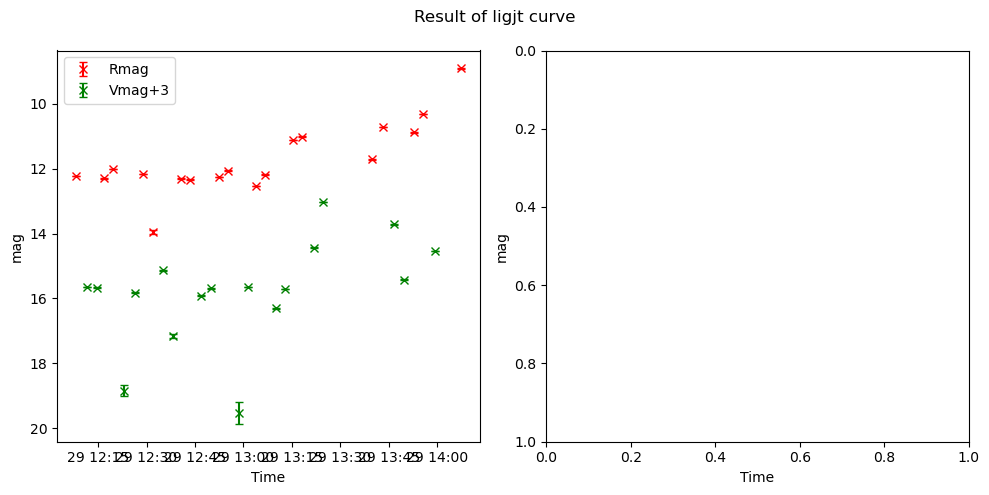

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False, gridspec_kw=None)

axs[0].errorbar(df_star["t_middle_dt"], 
            df_star['R_magnitude'], yerr=abs(df_star["merr_ann"]),
            marker='x',
            ecolor="red",
            mfc='red',
            mec='red',
            ls='none',
            #ms=10,
            capsize=3,
            label="Rmag")
axs[0].errorbar(df_star["t_middle_dt"], 
            df_star['V_magnitude']+3, yerr=abs(df_star["merr_ann"]),
            marker='x',
            # ecolor="yellow",
            # mfc='yellow',
            # mec='yellow',
            ecolor="green",
            mfc='green',
            mec='green',
            ls='none',
            #ms=10,
            capsize=3,
            label="Vmag+3")

axs[0].invert_yaxis()  
axs[0].set(
    xlabel='Time',
    ylabel="mag"
)
axs[0].legend()

axs[1].invert_yaxis()
axs[1].set(
    xlabel=f"Time",
    ylabel="mag"
)

plt.suptitle(f"Result of ligjt curve", fontsize=12,)

plt.tight_layout()
# plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization1.png")

# plt.show()
# plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


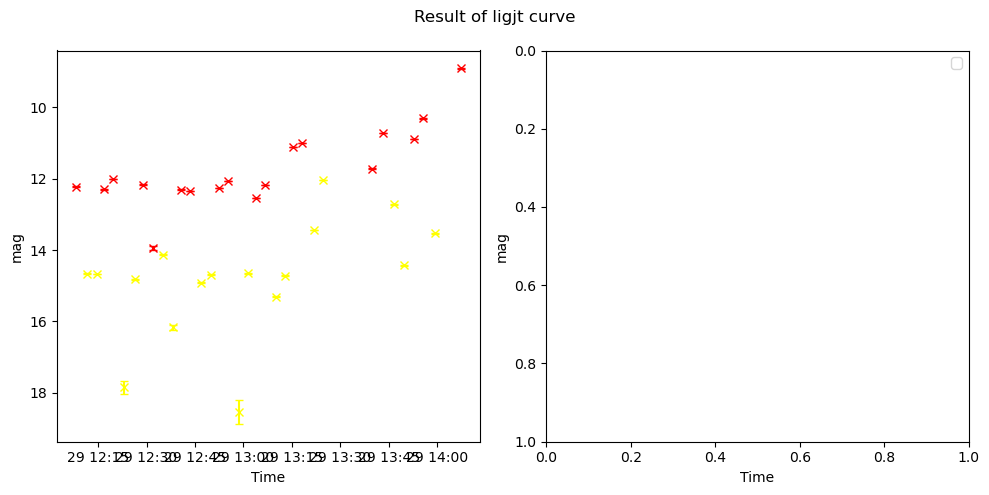

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False, gridspec_kw=None)

for idx, row in df_star.iterrows():

    axs[0].errorbar(row["t_middle_dt"], 
                row['R_magnitude'], yerr=abs(row["merr_ann"]),
                marker='x',
                ecolor="red",
                mfc='red',
                mec='red',
                ls='none',
                #ms=10,
                capsize=3,
                label="Rmag")
    axs[0].errorbar(row["t_middle_dt"], 
                row['V_magnitude']+2, yerr=abs(row["merr_ann"]),
                marker='x',
                ecolor="yellow",
                mfc='yellow',
                mec='yellow',
                ls='none',
                #ms=10,
                capsize=3,
                label="Vmag")

axs[0].invert_yaxis()
axs[1].invert_yaxis()
    
axs[0].set(
    xlabel='Time',
    ylabel="mag"
)
axs[1].set(
    xlabel=f"Time",
    ylabel="mag"
)

plt.legend()
plt.suptitle(f"Result of ligjt curve", fontsize=12,)

plt.tight_layout()
# plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization1.png")

# plt.show()
# plt.close()